# 1- Transfer Learning Setup

Augmenting data/raw\cardboard: 299 -> 300...
Augmenting data/raw\glass: 299 -> 300...
Augmenting data/raw\metal: 297 -> 300...
Augmenting data/raw\plastic: 295 -> 300...
Found 960 images belonging to 4 classes.
Found 240 images belonging to 4 classes.

Training images: 960
Validation images: 240


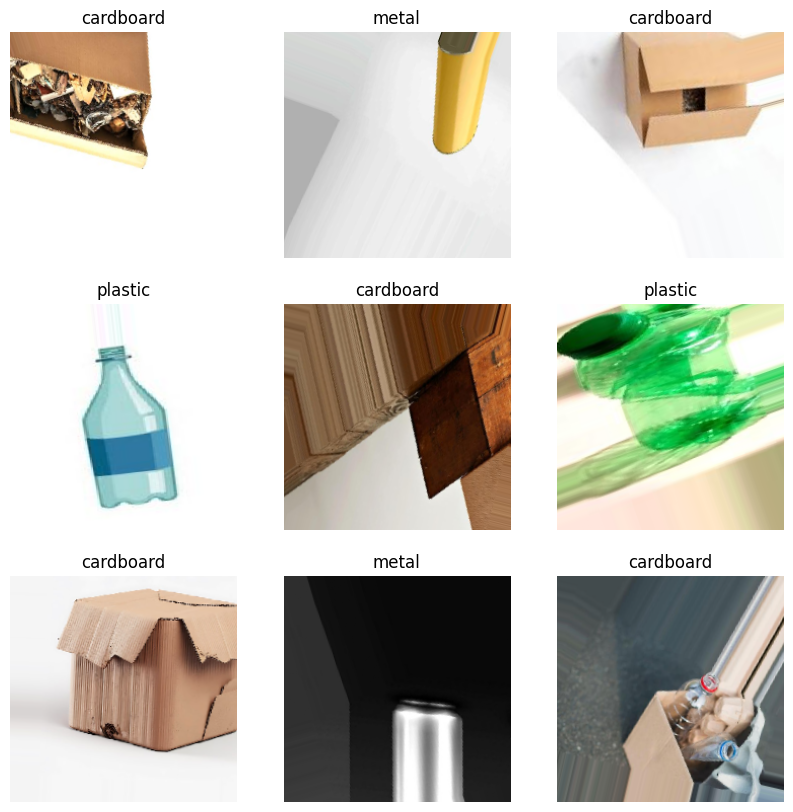

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 4,012,672 (15.31 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [1]:
import tensorflow as tf
from keras import layers, Model
from keras.applications import EfficientNetB0
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import preprocessing

NUM_CLASSES = 4  # plastic, metal, glass, cardboard
IMG_SIZE = (224, 224)

def build_model_finetune(num_classes):
    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3)
    )
    base_model.trainable = True  # Unfreeze everything from the start

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)          # Simpler head — less to overfit
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return Model(inputs, outputs), base_model

model, base_model = build_model_finetune(NUM_CLASSES)
model.summary()

# 2- Train head only (base unfrozen)

In [2]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),   # Low LR protects pretrained weights
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor="val_accuracy"),
    ReduceLROnPlateau(factor=0.5, patience=4, monitor="val_loss", verbose=1),
    ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_accuracy")
]

history = model.fit(
    preprocessing.train_generator,
    epochs=50,
    validation_data=preprocessing.val_generator,
    callbacks=callbacks,
)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 254s 3s/step - accuracy: 0.6573 - loss: 0.9007 - val_accuracy: 0.8667 - val_loss: 0.4048 - learning_rate: 1.0000e-04
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - accuracy: 0.8948 - loss: 0.3665 - val_accuracy: 0.9417 - val_loss: 0.1916 - learning_rate: 1.0000e-04
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 181s 3s/step - accuracy: 0.9271 - loss: 0.2289 - val_accuracy: 0.9542 - val_loss: 0.1372 - learning_rate: 1.0000e-04
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 173s 3s/step - accuracy: 0.9500 - loss: 0.1617 - val_accuracy: 0.9625 - val_loss: 0.1212 - learning_rate: 1.0000e-04
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 170s 3s/step - accuracy: 0.9615 - loss: 0.1257 - val_accuracy: 0.9625 - val_loss: 0.1055 - learning_rate: 1.0000e-04
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - accuracy: 0.9729 - loss: 0.0983 - val_accuracy: 0.9625 - val_loss: 0.1089 - learning_rate: 1.0000e-04
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 183s 3s/step - accuracy: 0.9771 

# 3- load and save best model

In [3]:
from keras.models import load_model

model = load_model("best_model.keras")
print("Model loaded successfully")

Model loaded successfully


# 4- Evaluate

In [ ]:
from keras.models import load_model
import preprocessing  


model = load_model("best_model.keras")
print(type(model))  
print("Loaded")


preprocessing.val_generator.reset()
loss, accuracy = model.evaluate(preprocessing.val_generator, verbose=1) #type: ignore
print(f"\nFinal Val Accuracy : {accuracy*100:.2f}%")
print(f"Final Val Loss     : {loss:.4f}")

<class 'keras.src.models.functional.Functional'>
Loaded
15/15 ━━━━━━━━━━━━━━━━━━━━ 25s 647ms/step - accuracy: 0.9750 - loss: 0.0901

Final Val Accuracy : 97.50%
Final Val Loss     : 0.0901


# 5- Confusion Matrix

15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 650ms/step

=== Classification Report ===
              precision    recall  f1-score   support

   cardboard       0.98      1.00      0.99        60
       glass       0.94      1.00      0.97        60
       metal       1.00      0.93      0.97        60
     plastic       0.98      0.97      0.97        60

    accuracy                           0.97       240
   macro avg       0.98      0.98      0.97       240
weighted avg       0.98      0.97      0.97       240



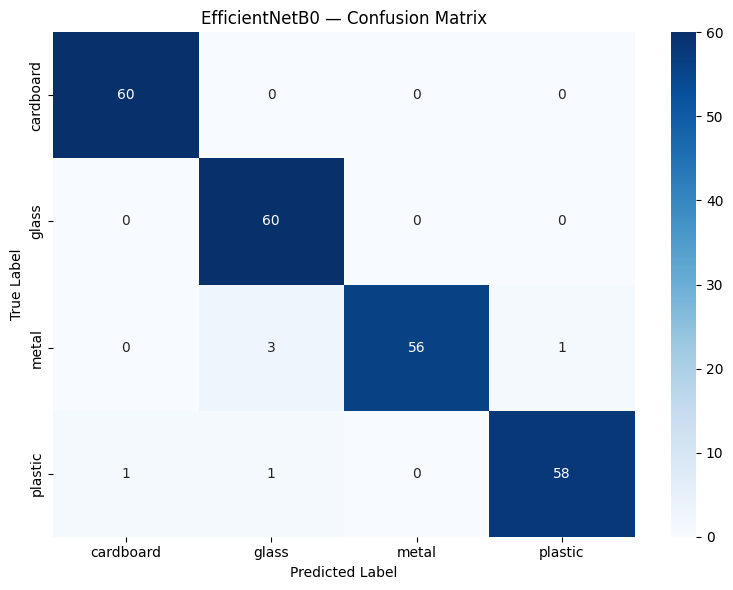

In [6]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

preprocessing.val_generator.reset()
y_pred_probs = model.predict(preprocessing.val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = preprocessing.val_generator.classes
CLASS_NAMES = list(preprocessing.val_generator.class_indices.keys())

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("EfficientNetB0 — Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# 6- MULTIMODELING (efficientnetb0 + LSTM)

## 6.1 Bin Routing Text + Tokenizer

In [8]:
import tensorflow as tf
from keras import layers, Model
from keras.models import load_model
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import matplotlib.pyplot as plt
import preprocessing

In [9]:
CLASS_TEXT = {
    'cardboard': 'cardboard paper waste goes in the blue recycling bin',
    'glass':     'glass bottle jar waste goes in the green glass bin',
    'metal':     'metal can tin waste goes in the yellow metal bin',
    'plastic':   'plastic bottle container goes in the red plastic bin',
}

CLASS_NAMES = sorted(CLASS_TEXT.keys())
texts       = [CLASS_TEXT[c] for c in CLASS_NAMES]

# Build vocab manually — no Tokenizer module needed
all_words   = ' '.join(texts).split()
vocab       = ['<PAD>'] + sorted(set(all_words))
word_to_idx = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE  = len(vocab)
MAX_SEQ_LEN = max(len(t.split()) for t in texts)

def encode(text):
    tokens = [word_to_idx[w] for w in text.split()]
    # pad to MAX_SEQ_LEN
    return tokens + [0] * (MAX_SEQ_LEN - len(tokens))

text_padded   = np.array([encode(t) for t in texts])
class_to_text = {i: text_padded[i] for i in range(len(CLASS_NAMES))}

print(f"Classes     : {CLASS_NAMES}")
print(f"Vocab size  : {VOCAB_SIZE}")
print(f"Seq length  : {MAX_SEQ_LEN}")
for i, name in enumerate(CLASS_NAMES):
    print(f"  [{i}] {name:<12} → {text_padded[i]}")

Classes     : ['cardboard', 'glass', 'metal', 'plastic']
Vocab size  : 21
Seq length  : 10
  [0] cardboard    → [ 5 13 19  8 10 17  2 15  1  0]
  [1] glass        → [ 7  3 11 19  8 10 17  9  7  1]
  [2] metal        → [12  4 18 19  8 10 17 20 12  1]
  [3] plastic      → [14  3  6  8 10 17 16 14  1  0]


## 6.2  Multimodal Generator

In [10]:
def make_multimodal_generator(image_gen, class_to_text):
    for images, labels in image_gen:
        class_indices = np.argmax(labels, axis=1)
        texts_batch   = np.array([class_to_text[idx] for idx in class_indices])
        yield (images, texts_batch), labels

## 6.3  Build Multimodal Model

In [11]:
trained_model = load_model("best_model.keras")
trained_model.trainable = False

feature_extractor = Model(
    inputs  = trained_model.input,
    outputs = trained_model.layers[-2].output,  # (None, 1280)
    name    = "efficientnet_features"
)
feature_extractor.trainable = False

# ── Image Branch ──────────────────────────────
image_input  = tf.keras.Input(shape=(224, 224, 3), name="image_input")
img_features = feature_extractor(image_input)       # (None, 1280)

# ── Text Branch ───────────────────────────────
text_input    = tf.keras.Input(shape=(MAX_SEQ_LEN,), name="text_input")
x             = layers.Embedding(VOCAB_SIZE, 64)(text_input)
x             = layers.LSTM(128)(x)
x             = layers.Dense(128, activation='relu')(x)
text_features = layers.Dropout(0.3)(x)              # (None, 128)

# ── Fusion ────────────────────────────────────
merged = layers.Concatenate(name="fusion")([img_features, text_features])
merged = layers.Dense(256, activation='relu')(merged)
merged = layers.Dropout(0.4)(merged)
merged = layers.Dense(128, activation='relu')(merged)
merged = layers.Dropout(0.3)(merged)
output = layers.Dense(4, activation='softmax', name="output")(merged)

multimodal_model = Model(
    inputs  = [image_input, text_input],
    outputs = output,
    name    = "multimodal_waste_classifier"
)

multimodal_model.compile(
    optimizer = Adam(learning_rate=1e-4),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

multimodal_model.summary()

Model: "multimodal_waste_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 10, 64)    │      1,344 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │     98,816 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnet_featu… │ (None, 1280)      │  4,049,571 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 1408)      │          0 │ efficientnet_fea… │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    360,704 │ fusion[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 4)         │        516 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,560,359 (17.40 MB)

 Trainable params: 510,788 (1.95 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 6.4 Train

In [12]:
preprocessing.train_generator.reset()
preprocessing.val_generator.reset()

train_mm = make_multimodal_generator(preprocessing.train_generator, class_to_text)
val_mm   = make_multimodal_generator(preprocessing.val_generator,   class_to_text)

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor="val_accuracy"),
    ModelCheckpoint("best_multimodal.keras", save_best_only=True, monitor="val_accuracy")
]

history_mm = multimodal_model.fit(
    train_mm,
    steps_per_epoch  = len(preprocessing.train_generator),
    epochs           = 30,
    validation_data  = val_mm,
    validation_steps = len(preprocessing.val_generator),
    callbacks        = callbacks
)

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.6125 - loss: 0.9903 - val_accuracy: 0.9708 - val_loss: 0.3838
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9469 - loss: 0.3285 - val_accuracy: 0.9792 - val_loss: 0.1624
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 53s 885ms/step - accuracy: 0.9833 - loss: 0.1442 - val_accuracy: 0.9792 - val_loss: 0.0834
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 51s 848ms/step - accuracy: 0.9906 - loss: 0.0569 - val_accuracy: 0.9792 - val_loss: 0.0522
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 52s 872ms/step - accuracy: 0.9937 - loss: 0.0310 - val_accuracy: 0.9833 - val_loss: 0.0343
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 47s 781ms/step - accuracy: 0.9990 - loss: 0.0109 - val_accuracy: 0.9958 - val_loss: 0.0215
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 50s 842ms/step - accuracy: 0.9990 - loss: 0.0065 - val_accuracy: 0.9958 - val_loss: 0.0137
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 52s 869ms/step - accuracy: 0.9990 - loss: 0.0047 - val_accuracy:

## 6.5 Confusion Matrix

              precision    recall  f1-score   support

   cardboard       1.00      1.00      1.00        60
       glass       1.00      1.00      1.00        60
       metal       1.00      1.00      1.00        60
     plastic       1.00      1.00      1.00        60

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



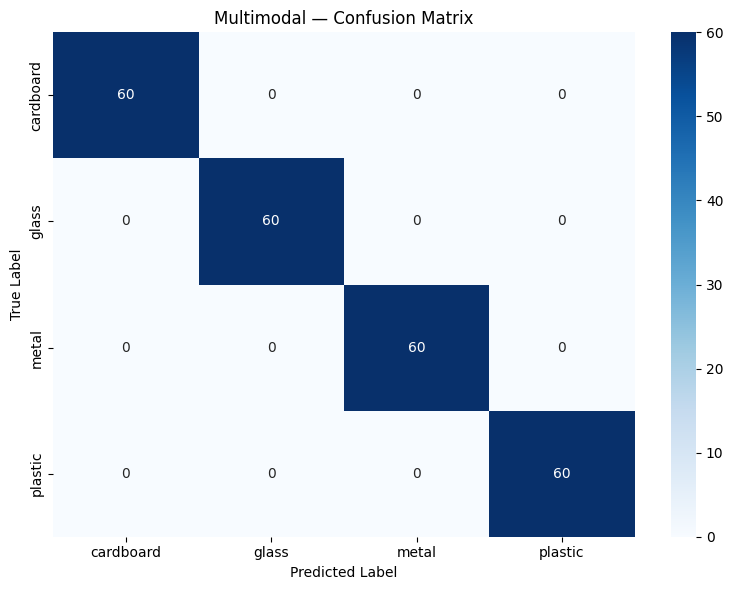

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

preprocessing.val_generator.reset()
val_mm_pred = make_multimodal_generator(preprocessing.val_generator, class_to_text)

y_pred_probs, y_true = [], []
for (imgs, txts), labels in val_mm_pred:
    preds    = multimodal_model.predict([imgs, txts], verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(np.argmax(labels, axis=1))
    if len(y_true) >= preprocessing.val_generator.samples:
        break

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.array(y_true)

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Multimodal — Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix_multimodal.png", dpi=150)
plt.show()

## 6.6 Inference

In [16]:
from keras.applications.efficientnet import preprocess_input

BIN_ROUTING = {
    'cardboard': ('Blue Bin',   'Paper & Cardboard Recycling'),
    'glass':     ('Green Bin',  'Glass Recycling'),
    'metal':     ('Yellow Bin', 'Metal & Cans Recycling'),
    'plastic':   ('Red Bin',    'Plastic Recycling'),
}

def predict_multimodal(img_path):
    img       = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    arr       = preprocess_input(tf.keras.utils.img_to_array(img))
    img_batch = np.expand_dims(arr, axis=0)

    all_probs = np.zeros(4)
    for class_idx in range(4):
        text_batch = np.expand_dims(class_to_text[class_idx], axis=0)
        probs      = multimodal_model.predict([img_batch, text_batch], verbose=0)[0]
        all_probs += probs
    all_probs /= 4

    predicted_idx   = np.argmax(all_probs)
    predicted_class = CLASS_NAMES[predicted_idx]
    confidence      = all_probs[predicted_idx]
    bin_name, bin_desc = BIN_ROUTING[predicted_class]

    print(f"\nWaste Type  : {predicted_class.upper()}")
    print(f"Throw in    : {bin_name} — {bin_desc}")
    print(f"Confidence  : {confidence*100:.1f}%")
    print("─" * 40)
    for name, p in zip(CLASS_NAMES, all_probs):
        bar = "█" * int(p * 40)
        print(f"  {name:<12} {p*100:5.1f}%  {bar}")

    plt.imshow(tf.keras.utils.load_img(img_path))
    plt.title(f"{predicted_class.upper()} → {bin_name}\n({confidence*100:.1f}%)")
    plt.axis("off")
    plt.show()

# Usage:
# predict_multimodal("data/raw/plastic/some_image.jpg")

In [19]:
import os

for cls in CLASS_NAMES:
    folder = f"data/raw/{cls}"
    first  = os.listdir(folder)[0]
    print(f"{cls:<12} → data/raw/{cls}/{first}")

cardboard    → data/raw/cardboard/aug_0_1003.jpg
glass        → data/raw/glass/aug_0_1040.jpg
metal        → data/raw/metal/aug_0_1004.jpg
plastic      → data/raw/plastic/5NGmdEdHLUpsgy9pi0saGctJdCv1wSVx_Rw20x4zysjKD5BzoQR14-W-IzfWdM57Az2ym5xNuMLvfMiYOWi5q8OMjcZN1Qp-K9cHEzqqEqgw4HeSIw6Lvnu5TVO76Pih1wGT0bpnvanctxaFZQfKdlSBkkGMdXE9C_RaSb5QMxRTJCaR5r6LHApPgPO54XVU.jpeg



Waste Type  : GLASS
Throw in    : Green Bin — Glass Recycling
Confidence  : 50.6%
────────────────────────────────────────
  cardboard      0.1%  
  glass         50.6%  ████████████████████
  metal         24.5%  █████████
  plastic       24.8%  █████████


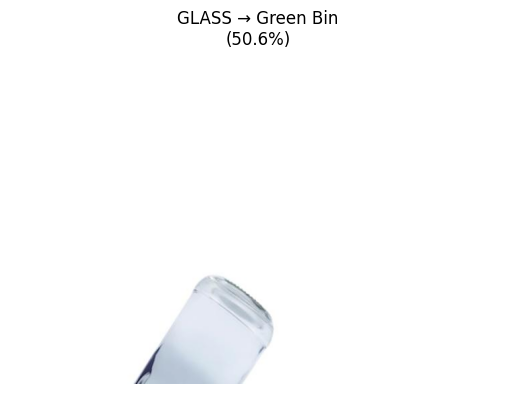

In [20]:
predict_multimodal("data/raw/glass/aug_0_1040.jpg")  